In [ ]:
import gc
import time
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Dense, Flatten, Conv2D, MaxPooling2D, Dropout,
                                      BatchNormalization, GlobalAveragePooling2D,
                                      Activation)
from tensorflow.keras import layers
from tensorflow.keras.datasets import mnist
from tensorflow.keras.preprocessing import image
gc.collect()
import joblib

**Import Libraries & Define Paths**




In [ ]:
import os
import zipfile

# Download dataset directly using Kaggle API command
!kaggle datasets download -d mohitsingh1804/plantvillage

# Extract the downloaded zip file
zip_filename = "plantvillage.zip"
if os.path.exists(zip_filename):
    with zipfile.ZipFile(zip_filename, 'r') as zip_ref:
        zip_ref.extractall("plant_dataset")
    print("Dataset downloaded and extracted successfully")
else:
    print("Please check the downloaded zip file name.")

Dataset URL: https://www.kaggle.com/datasets/mohitsingh1804/plantvillage
License(s): GPL-2.0
100% 818M/818M [00:07<00:00, 115MB/s]

Dataset downloaded and extracted successfully


**Load Images**

In [ ]:
import os

DATADIR = "/content/plant_dataset/PlantVillage/train"

# Check available classes/categories
categories = sorted(os.listdir(DATADIR))
print(f"Total Number of Classes: {len(categories)}")
print(f"Sample Classes: {categories[:5]}")

Total Number of Classes: 38
Sample Classes: ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy']


**Load, Resize, and Normalize Images**

In [ ]:
import cv2
import numpy as np
import gc

gc.collect() # Clear memory to prevent RAM crash
IMG_SIZE = 64  # Resize images to 64x64 to optimize RAM usage
data = []

print("Loading and preprocessing dataset...")
for category in categories:
    path = os.path.join(DATADIR, category)
    if not os.path.isdir(path):
        continue

    class_num = categories.index(category)
    for img in os.listdir(path):
        try:
            img_path = os.path.join(path, img)
            img_array = cv2.imread(img_path, cv2.IMREAD_COLOR)
            if img_array is not None:
                # Resize image and append to dataset list
                resized_array = cv2.resize(img_array, (IMG_SIZE, IMG_SIZE))
                data.append([resized_array, class_num])
        except:
            pass


Loading and preprocessing dataset...


Separate features (X) and labels (y)

In [ ]:
X = []
y = []
for features, label in data:
    X.append(features)
    y.append(label)

# Convert lists to NumPy arrays and apply Pixel Normalization [0.0, 1.0]
X = np.array(X, dtype=np.float32) / 255.0
y = np.array(y)

print(f"Total Images Loaded & Preprocessed: {X.shape[0]}")
gc.collect()

Total Images Loaded & Preprocessed: 43444


0

**Split dataset into Training (80%) and Temporary (20%) using stratify to maintain class distribution**

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(X, y,test_size=0.20,random_state=42,stratify=y)

print(f"Training Set (80%):  {X_train.shape[0]} images")
print(f"Temporary Set (20%): {X_temp.shape[0]} images")

Training Set (80%):  34755 images
Temporary Set (20%): 8689 images


**Split the 20% temporary set equally into Validation (10%) and Testing (10%) with stratify**

In [ ]:
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp,test_size=0.50,random_state=42,stratify=y_temp)

print(f"Training Set (80%):   {X_train.shape[0]} images -> Shape: {X_train.shape}")
print(f"Validation Set (10%): {X_val.shape[0]} images -> Shape: {X_val.shape}")
print(f"Testing Set (10%):    {X_test.shape[0]} images -> Shape: {X_test.shape}")

gc.collect() # Final memory cleanup

Training Set (80%):   34755 images -> Shape: (34755, 64, 64, 3)
Validation Set (10%): 4344 images -> Shape: (4344, 64, 64, 3)
Testing Set (10%):    4345 images -> Shape: (4345, 64, 64, 3)


0

**Random Image**

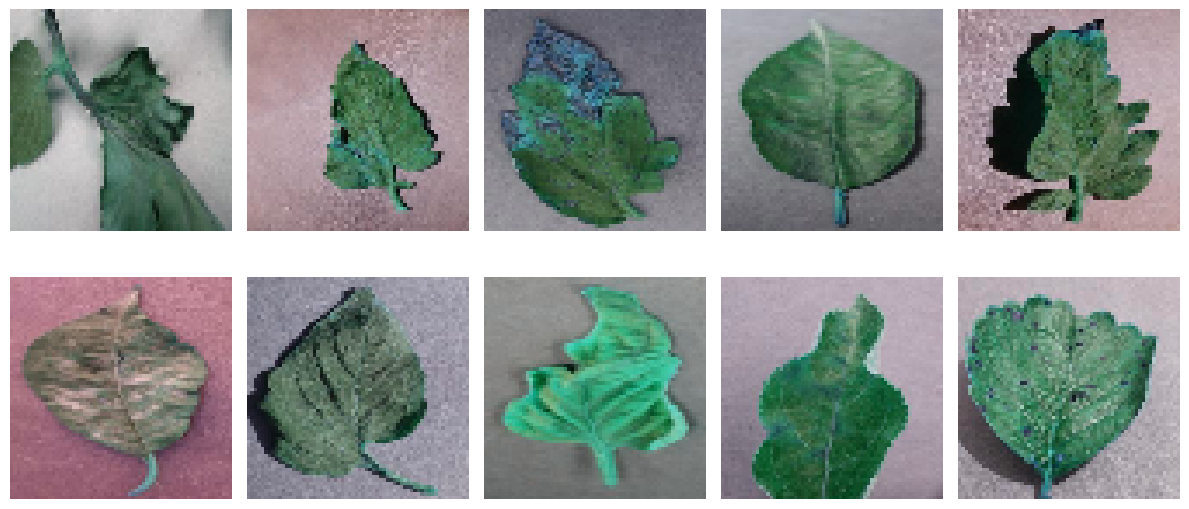

In [ ]:
import matplotlib.pyplot as plt

random_indices = np.random.choice(len(X_train), 10, replace=False)

plt.figure(figsize=(12, 6))
for i, index in enumerate(random_indices):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[index])
    plt.axis('off')

plt.tight_layout()
plt.show()

**Build Improved CNN Model**

This version keeps the original 64x64 input and 38 classes, while using BatchNormalization, deeper convolution blocks, GlobalAveragePooling2D, and stronger training callbacks.


In [ ]:
model = Sequential([
    layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),

    # Data Augmentation
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),

    # Block 1
    Conv2D(32, (3, 3), padding="same", use_bias=False),
    BatchNormalization(),
    Activation("relu"),
    Conv2D(32, (3, 3), padding="same", use_bias=False),
    BatchNormalization(),
    Activation("relu"),
    MaxPooling2D((2, 2)),
    Dropout(0.20),

    # Block 2
    Conv2D(64, (3, 3), padding="same", use_bias=False),
    BatchNormalization(),
    Activation("relu"),
    Conv2D(64, (3, 3), padding="same", use_bias=False),
    BatchNormalization(),
    Activation("relu"),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    # Block 3
    Conv2D(128, (3, 3), padding="same", use_bias=False),
    BatchNormalization(),
    Activation("relu"),
    Conv2D(128, (3, 3), padding="same", use_bias=False),
    BatchNormalization(),
    Activation("relu"),
    MaxPooling2D((2, 2)),
    Dropout(0.30),

    # Classification Head
    GlobalAveragePooling2D(),
    Dense(256, use_bias=False),
    BatchNormalization(),
    Activation("relu"),
    Dropout(0.40),
    Dense(38, activation="softmax")
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip (RandomFlip)        │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 64, 64, 3)      │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 7, 7, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 3, 3, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 3, 3, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 2, 2, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 1, 1, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1, 1, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 38)             │         9,766 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 136,038 (531.40 KB)

 Trainable params: 136,038 (531.40 KB)

 Non-trainable params: 0 (0.00 B)

**Compile & Fit**

In [ ]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

early_stop = EarlyStopping(
    monitor="val_accuracy",
    patience=6,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

checkpoint = ModelCheckpoint(
    "best_CNN_model.keras",
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)

start_time = time.time()
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=64,
    validation_data=(X_val, y_val),
    callbacks=[early_stop, reduce_lr, checkpoint],
    verbose=1
)
end_time = time.time()
print(f"Training time: {end_time - start_time:.2f} seconds")

Epoch 1/50
1087/1087 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.3093 - loss: 2.5208 - val_accuracy: 0.5083 - val_loss: 1.7266
Epoch 2/50
1087/1087 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.5147 - loss: 1.6678 - val_accuracy: 0.5992 - val_loss: 1.3202
Epoch 3/50
1087/1087 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.5876 - loss: 1.3853 - val_accuracy: 0.6706 - val_loss: 1.1012
Epoch 4/50
1087/1087 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.6307 - loss: 1.2261 - val_accuracy: 0.7044 - val_loss: 0.9488
Epoch 5/50
1087/1087 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.6619 - loss: 1.1165 - val_accuracy: 0.7590 - val_loss: 0.7817
Epoch 6/50
1087/1087 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.6869 - loss: 1.0132 - val_accuracy: 0.7484 - val_loss: 0.7757
Epoch 7/50
1087/1087 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.7098 - loss: 0.9438 - val_accuracy: 0.7709 - val_loss: 0.7178
Epoch 8/50
1087/1087 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.7210 - loss: 0.9021

**Save Model**

In [ ]:
# Save the final trained model in the modern Keras format
model.save("CNN_model_improved.keras")
print("Model saved successfully as CNN_model_improved.keras")

saved successfully


In [ ]:
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=1)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

136/136 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8649 - loss: 0.4111
Test Loss: 0.4111
Test Accuracy: 86.49%


In [ ]:
import numpy as np

y_pred_probs = model.predict(X_test)

y_pred = np.argmax(y_pred_probs, axis=1)

print("Predictions completed successfully!")

136/136 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Predictions completed successfully!


In [ ]:
from sklearn.metrics import classification_report

report = classification_report(
    y_test,
    y_pred,
    target_names=class_names
)

print(report)

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.83      0.48      0.61        50
                                 Apple___Black_rot       0.72      0.67      0.69        49
                          Apple___Cedar_apple_rust       0.57      0.59      0.58        22
                                   Apple___healthy       0.91      0.83      0.87       132
                               Blueberry___healthy       0.84      0.95      0.89       120
          Cherry_(including_sour)___Powdery_mildew       0.87      0.98      0.92        84
                 Cherry_(including_sour)___healthy       0.95      0.81      0.87        68
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.69      0.44      0.54        41
                       Corn_(maize)___Common_rust_       0.98      0.95      0.96        95
               Corn_(maize)___Northern_Leaf_Blight       0.80      0.84      0.

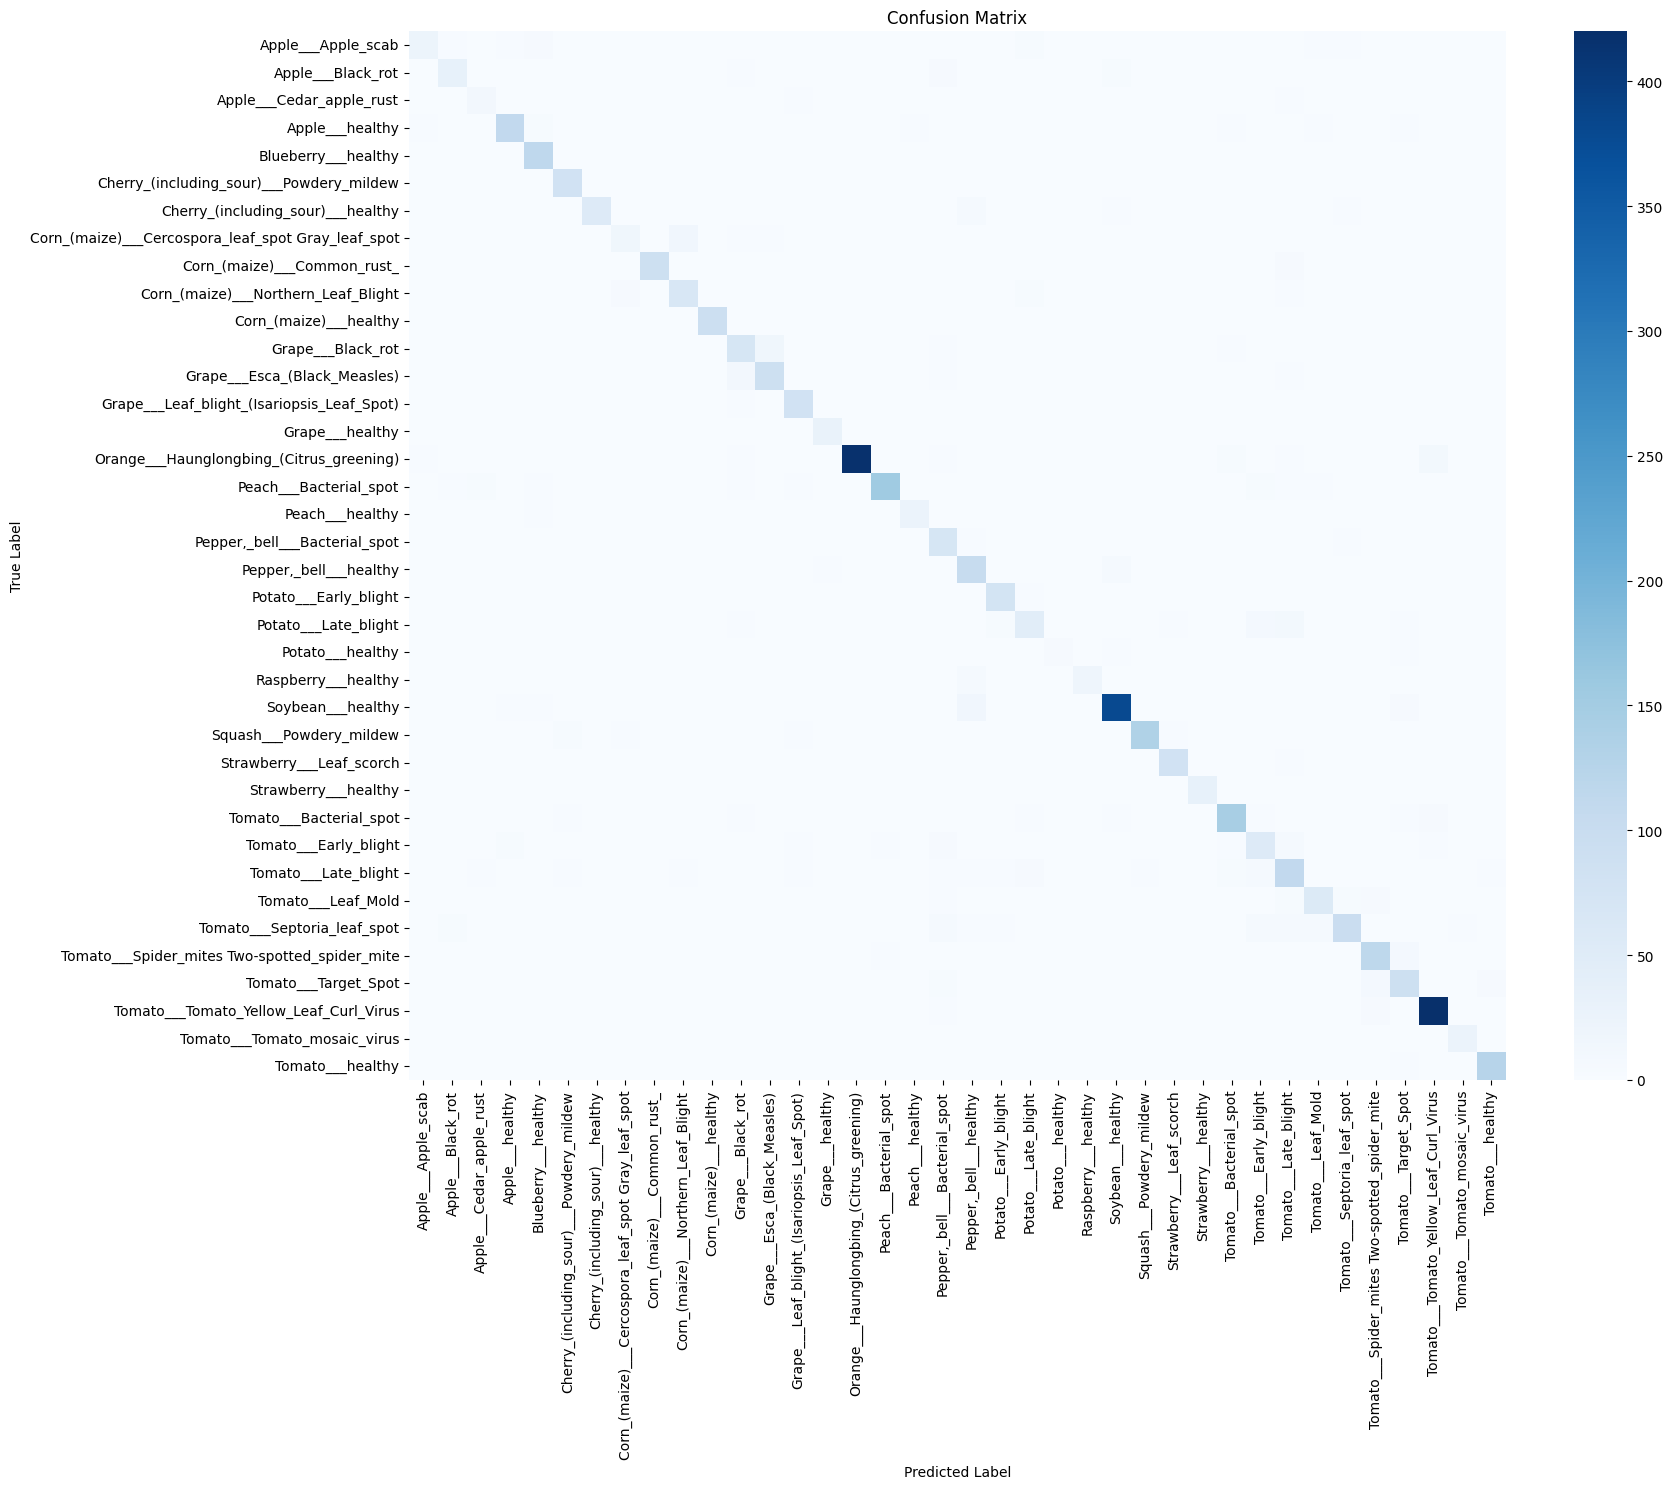

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(18, 15))
sns.heatmap(
    cm,
    annot=False,
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving 4633813-sweet-apple-with-leaf.jpg to 4633813-sweet-apple-with-leaf.jpg


In [ ]:
import cv2
import numpy as np

# اسم الصورة
file_path = "4633813-sweet-apple-with-leaf.jpg"

# قراءة الصورة
img = cv2.imread(file_path, cv2.IMREAD_COLOR)

# Resize to the same size used during training
img_resized = cv2.resize(img, (64, 64))

# Normalize
img_normalized = img_resized.astype("float32") / 255.0

# Add batch dimension
img_input = np.expand_dims(img_normalized, axis=0)

# Prediction
pred_probs = model.predict(img_input)

# Get predicted class
pred_class = np.argmax(pred_probs[0])

# Get confidence
confidence = np.max(pred_probs[0]) * 100

# Get class name
predicted_name = class_names[pred_class]

print("Predicted Class:", predicted_name)
print(f"Confidence: {confidence:.2f}%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 400ms/step
Predicted Class: Strawberry___Leaf_scorch
Confidence: 100.00%


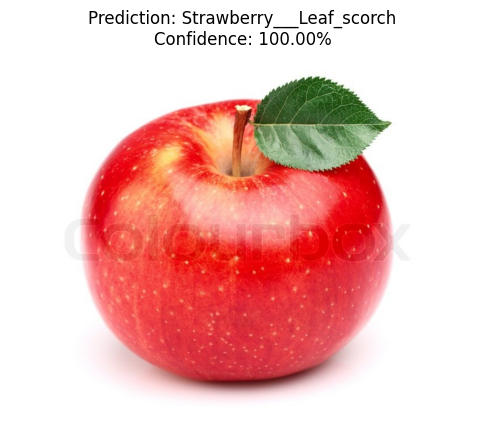

In [ ]:
import matplotlib.pyplot as plt

# Convert BGR to RGB for displaying
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(6, 6))
plt.imshow(img_rgb)
plt.axis("off")
plt.title(f"Prediction: {predicted_name}\nConfidence: {confidence:.2f}%")
plt.show()

In [ ]:
import gradio as gr
import cv2
import numpy as np
import tensorflow as tf

# Load model if it is not already loaded
if 'model' not in globals():
    model = tf.keras.models.load_model("CNN_model_improved.keras")

# Make sure class names exist
if 'class_names' not in globals():
    class_names = categories


def predict_disease(image_path):

    # Read image using OpenCV
    img = cv2.imread(image_path, cv2.IMREAD_COLOR)

    # Resize
    img_resized = cv2.resize(img, (64, 64))

    # Normalize
    img_normalized = img_resized.astype("float32") / 255.0

    # Add batch dimension
    img_input = np.expand_dims(img_normalized, axis=0)

    # Prediction
    pred_probs = model.predict(img_input, verbose=0)

    # Get predicted class
    pred_class = np.argmax(pred_probs[0])

    # Get confidence
    confidence = np.max(pred_probs[0]) * 100

    # Get class name
    predicted_name = class_names[pred_class]

    return predicted_name, f"{confidence:.2f}%"


# Create the interface
demo = gr.Interface(
    fn=predict_disease,
    inputs=gr.Image(
        type="filepath",
        label="Upload Plant Leaf Image"
    ),
    outputs=[
        gr.Textbox(label="Predicted Disease"),
        gr.Textbox(label="Confidence")
    ],
    title="🌿 Plant Disease Detection",
    description="Upload an image of a plant leaf to predict its disease."
)

# Launch
demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://bf19be448a83fbee2a.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
